# Quoridor AlphaZero Self-Play - Notebook

A self-contained notebook for training an AlphaZero-style model on Quoridor through self-play.

It brings the full training pipeline into one readable flow:
- game logic and action encoding
- policy-value neural network
- Monte Carlo Tree Search
- self-play training loop
- replay buffer, metrics, and checkpoints

In [1]:
# ============================================================
# 1. IMPORTS, DEVICE, OUTPUT FOLDERS
# ============================================================

from collections import deque
from dataclasses import dataclass
from datetime import datetime
from zoneinfo import ZoneInfo
from pathlib import Path
import csv
import json
import math
import random
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

RUN_TIMESTAMP = datetime.now(ZoneInfo("Europe/Rome")).strftime("%Y%m%d_%H%M%S")

# Output directory:
# - Colab: salva su Google Drive, cosi i checkpoint sopravvivono al runtime.
# - RunPod: salva su /workspace, che di solito e il volume persistente.
# - Locale: salva nella cartella corrente.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR = Path('/content/drive/MyDrive/quoridor_alphazero_runs')
    RUN_ENV = 'colab'
except Exception:
    if Path('/workspace').exists():
        OUTPUT_DIR = Path('/workspace/quoridor_alphazero_runs')
        RUN_ENV = 'runpod'
    else:
        OUTPUT_DIR = Path('quoridor_alphazero_runs')
        RUN_ENV = 'local'

print('Run environment:', RUN_ENV)

RUN_DIR = OUTPUT_DIR / f'run_{RUN_TIMESTAMP}'
MODEL_DIR = RUN_DIR / 'models'
METRICS_DIR = RUN_DIR / 'metrics'
PLOTS_DIR = RUN_DIR / 'plots'

for folder in [MODEL_DIR, METRICS_DIR, PLOTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print('Run dir:', RUN_DIR)

# Per risultati piu riproducibili.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)


Device: cpu
Run environment: local
Run dir: quoridor_alphazero_runs\run_20260610_224209


In [2]:
# ============================================================
# 2. GAME LOGIC AND ACTION ENCODING
# ============================================================

from collections import deque

import numpy as np

P1 = 1
P2 = 2

MOVE_ACTIONS = [
    "up",
    "down",
    "left",
    "right",
    "up-jump",
    "down-jump",
    "left-jump",
    "right-jump",
    "up-left",
    "up-right",
    "down-left",
    "down-right",
    "left-up",
    "left-down",
    "right-up",
    "right-down",
]
NUM_MOVE_ACTIONS = len(MOVE_ACTIONS)
# Board configuration defaults for the fast training variant.
# To train on classic Quoridor, set board_size=9 and max_walls=10 in CONFIG.
DEFAULT_GRID_SIZE = 5
DEFAULT_MAX_WALLS = 4


def num_wall_positions_for_grid(grid_size):
    return (grid_size - 1) ** 2


def total_actions_for_grid(grid_size):
    return NUM_MOVE_ACTIONS + 2 * num_wall_positions_for_grid(grid_size)


NUM_WALL_POS = num_wall_positions_for_grid(DEFAULT_GRID_SIZE)
TOTAL_ACTIONS = total_actions_for_grid(DEFAULT_GRID_SIZE)
BASE_DIRECTIONS = {
    "up": (-1, 0),
    "down": (1, 0),
    "left": (0, -1),
    "right": (0, 1),
}
PATH_DIRECTIONS = tuple(BASE_DIRECTIONS.values())


def flip_direction_for_p2(direction):
    """
    P2 is normalized with a vertical flip only.

    e.g.
    - "up" -> "down"
    - "down-jump" -> "up-jump"
    - "left" stays "left"
    """
    parts = direction.split("-")
    flipped_parts = []

    for part in parts:
        if part == "up":
            flipped_parts.append("down")
        elif part == "down":
            flipped_parts.append("up")
        else:
            flipped_parts.append(part)

    return "-".join(flipped_parts)


class GridGameAi:
    """
    Quoridor game state used by the AlphaZero / MCTS pipeline.

    Main ideas:
    - the object stores the real board
    - the network sees canonical player-centric states
    - MCTS clones this object to explore hypothetical continuations
    """

    def __init__(self, grid_size=DEFAULT_GRID_SIZE, max_walls=DEFAULT_MAX_WALLS):
        self.grid_size = grid_size
        self.max_walls = max_walls
        self.num_wall_positions = num_wall_positions_for_grid(grid_size)
        self.total_actions = total_actions_for_grid(grid_size)
        self.reset()

    def reset(self):
        self.grid = np.zeros((self.grid_size, self.grid_size), dtype=int)

        self.p1_pos = np.array([self.grid_size - 1, self.grid_size // 2])
        self.p2_pos = np.array([0, self.grid_size // 2])

        self.grid[self.p1_pos[0], self.p1_pos[1]] = P1
        self.grid[self.p2_pos[0], self.p2_pos[1]] = P2

        self.p1_horizontal_walls = set()
        self.p1_vertical_walls = set()
        self.p2_horizontal_walls = set()
        self.p2_vertical_walls = set()

        self.p1_available_walls = self.max_walls
        self.p2_available_walls = self.max_walls
        self.turn = P1
        self._valid_actions_cache = {}

    def clone(self):
        cloned = self.__class__.__new__(self.__class__)
        cloned.grid_size = self.grid_size
        cloned.max_walls = self.max_walls
        cloned.num_wall_positions = self.num_wall_positions
        cloned.total_actions = self.total_actions
        cloned.grid = self.grid.copy()
        cloned.p1_pos = self.p1_pos.copy()
        cloned.p2_pos = self.p2_pos.copy()
        cloned.p1_horizontal_walls = set(self.p1_horizontal_walls)
        cloned.p1_vertical_walls = set(self.p1_vertical_walls)
        cloned.p2_horizontal_walls = set(self.p2_horizontal_walls)
        cloned.p2_vertical_walls = set(self.p2_vertical_walls)
        cloned.p1_available_walls = self.p1_available_walls
        cloned.p2_available_walls = self.p2_available_walls
        cloned.turn = self.turn
        cloned._valid_actions_cache = {
            player: actions.copy()
            for player, actions in self._valid_actions_cache.items()
        }
        return cloned

    def _invalidate_action_cache(self):
        # Legal actions depend on pawn positions, walls, wall counts, and turn.
        # Any real state mutation clears cached actions for both players.
        self._valid_actions_cache.clear()

    def get_current_player(self):
        return self.turn

    def _flip_wall_row_for_p2(self, row):
        return (self.grid_size - 2) - row

    def _transform_wall_row(self, row, player):
        if player == P1:
            return row
        return self._flip_wall_row_for_p2(row)

    def decode_action(self, action, player=None):
        if player is None:
            player = self.turn

        if action < NUM_MOVE_ACTIONS:
            direction = MOVE_ACTIONS[action]
            if player == P2:
                direction = flip_direction_for_p2(direction)
            return "move", direction

        if action < NUM_MOVE_ACTIONS + self.num_wall_positions:
            wall_index = action - NUM_MOVE_ACTIONS
            row = wall_index // (self.grid_size - 1)
            col = wall_index % (self.grid_size - 1)
            if player == P2:
                row = self._flip_wall_row_for_p2(row)
            return "wall", (row, col), "h"

        wall_index = action - NUM_MOVE_ACTIONS - self.num_wall_positions
        row = wall_index // (self.grid_size - 1)
        col = wall_index % (self.grid_size - 1)
        if player == P2:
            row = self._flip_wall_row_for_p2(row)
        return "wall", (row, col), "v"

    def encode_action(self, action_type, *args, player=None):
        if player is None:
            player = self.turn

        if action_type == "move":
            direction = args[0]
            if player == P2:
                direction = flip_direction_for_p2(direction)
            return MOVE_ACTIONS.index(direction)

        if action_type == "wall":
            row, col = args[0]
            orientation = args[1]
            if player == P2:
                row = self._flip_wall_row_for_p2(row)

            wall_index = row * (self.grid_size - 1) + col
            if orientation == "h":
                return NUM_MOVE_ACTIONS + wall_index
            return NUM_MOVE_ACTIONS + self.num_wall_positions + wall_index

        raise ValueError(f"Invalid action encoding: {action_type}, {args}")

    def get_state_player_centric(self, player):
        """
        Canonical network input with 6 planes:
        0 = current player
        1 = opponent
        2 = horizontal walls
        3 = vertical walls
        4 = my remaining walls
        5 = opponent remaining walls
        """
        size = self.grid_size
        state = np.zeros((6, size, size), dtype=np.float32)

        if player == P1:
            my_pos = self.p1_pos
            opp_pos = self.p2_pos
            my_horizontal_walls = self.p1_horizontal_walls
            opp_horizontal_walls = self.p2_horizontal_walls
            my_vertical_walls = self.p1_vertical_walls
            opp_vertical_walls = self.p2_vertical_walls
            my_available_walls = self.p1_available_walls
            opp_available_walls = self.p2_available_walls
            row_transform = lambda row: row
        else:
            my_pos = self.p2_pos
            opp_pos = self.p1_pos
            my_horizontal_walls = self.p2_horizontal_walls
            opp_horizontal_walls = self.p1_horizontal_walls
            my_vertical_walls = self.p2_vertical_walls
            opp_vertical_walls = self.p1_vertical_walls
            my_available_walls = self.p2_available_walls
            opp_available_walls = self.p1_available_walls
            row_transform = lambda row: size - 1 - row

        state[0, row_transform(my_pos[0]), my_pos[1]] = 1.0
        state[1, row_transform(opp_pos[0]), opp_pos[1]] = 1.0

        for r, c in my_horizontal_walls:
            state[2, self._transform_wall_row(r, player), c] = 1.0
        for r, c in opp_horizontal_walls:
            state[2, self._transform_wall_row(r, player), c] = 1.0

        for r, c in my_vertical_walls:
            state[3, self._transform_wall_row(r, player), c] = 1.0
        for r, c in opp_vertical_walls:
            state[3, self._transform_wall_row(r, player), c] = 1.0

        wall_scale = max(1, self.max_walls)
        state[4, :, :] = my_available_walls / wall_scale
        state[5, :, :] = opp_available_walls / wall_scale

        return state

    def get_canonical_state(self, player=None):
        if player is None:
            player = self.turn
        return self.get_state_player_centric(player)

    def get_state(self):
        return self.get_canonical_state(self.turn)

    def get_action_mask(self, player):
        mask = np.zeros(self.total_actions, dtype=np.float32)
        mask[self.get_valid_actions(player)] = 1.0
        return mask

    def get_valid_actions(self, player=None):
        if player is None:
            player = self.turn

        cached_actions = self._valid_actions_cache.get(player)
        if cached_actions is not None:
            return cached_actions.copy()

        actions = []
        for move in self.available_moves(player):
            actions.append(self.encode_action(*move, player=player))

        for row in range(self.grid_size - 1):
            for col in range(self.grid_size - 1):
                if self._is_valid_wall(player, (row, col), "h"):
                    actions.append(
                        self.encode_action("wall", (row, col), "h", player=player)
                    )
                if self._is_valid_wall(player, (row, col), "v"):
                    actions.append(
                        self.encode_action("wall", (row, col), "v", player=player)
                    )

        valid_actions = np.array(actions, dtype=np.int64)
        self._valid_actions_cache[player] = valid_actions
        return valid_actions.copy()

    def is_terminal(self):
        return self.check_winner() is not None

    def get_winner(self):
        return self.check_winner()

    def get_outcome_for_player(self, player):
        winner = self.check_winner()
        if winner is None:
            return 0
        return 1 if winner == player else -1

    def shortest_path_distance_to_goal(self, player):
        """
        Return the fewest pawn moves needed for `player` to reach its goal row.

        This is used only as a soft timeout adjudication signal: when self-play
        hits the move limit, the player with the shorter legal path is treated
        as slightly ahead instead of labeling the whole unfinished game a draw.
        """
        if player == P1:
            start = self.p1_pos
            target_row = 0
        else:
            start = self.p2_pos
            target_row = self.grid_size - 1

        start_pos = (int(start[0]), int(start[1]))
        visited = {start_pos}
        queue = deque([(start_pos, 0)])

        while queue:
            (row, col), distance = queue.popleft()
            if row == target_row:
                return distance

            for drow, dcol in PATH_DIRECTIONS:
                nrow, ncol = row + drow, col + dcol
                next_pos = (nrow, ncol)
                if (
                    nrow < 0
                    or nrow >= self.grid_size
                    or ncol < 0
                    or ncol >= self.grid_size
                ):
                    continue
                if next_pos in visited:
                    continue
                if self.is_blocked((row, col), next_pos):
                    continue

                visited.add(next_pos)
                queue.append((next_pos, distance + 1))

        return float("inf")

    def get_timeout_adjudication_winner(self):
        """
        Pick a soft winner for unfinished games by shortest legal path length.

        Equal distances remain a real draw, because neither side has a clear
        distance advantage at the truncation point.
        """
        p1_distance = self.shortest_path_distance_to_goal(P1)
        p2_distance = self.shortest_path_distance_to_goal(P2)

        if p1_distance < p2_distance:
            return P1
        if p2_distance < p1_distance:
            return P2
        return None

    def step(self, action):
        """
        Apply one canonical action index.

        Output:
        - next canonical state for the new player to move
        - done
        - info
        """
        player = self.turn
        decoded = self.decode_action(action, player=player)

        if decoded[0] == "move":
            _, direction = decoded
            try:
                self.move(player, ("move", direction))
            except ValueError:
                return self.get_state(), False, {"invalid": True, "winner": None}
        else:
            _, location, orientation = decoded
            success, _ = self.place_wall(player, location, orientation)
            if not success:
                return self.get_state(), False, {"invalid": True, "winner": None}

        winner = self.check_winner()
        done = winner is not None
        return self.get_state(), done, {"invalid": False, "winner": winner}

    def apply_action(self, action):
        return self.step(action)

    def next_state(self, action):
        cloned_state = self.clone()
        cloned_state.apply_action(action)
        return cloned_state

    def next_state_from_valid_action(self, action):
        cloned_state = self.clone()
        cloned_state._apply_valid_action_without_rechecking(action)
        return cloned_state

    def _apply_valid_action_without_rechecking(self, action):
        action_type, *decoded_args = self.decode_action(action, player=self.turn)

        if action_type == "move":
            self._move_without_rechecking(self.turn, decoded_args[0])
        else:
            location, orientation = decoded_args
            self._place_wall_without_rechecking(self.turn, location, orientation)

    def to_dict(self):
        return {
            "grid_size": self.grid_size,
            "max_walls": self.max_walls,
            "num_wall_positions": self.num_wall_positions,
            "total_actions": self.total_actions,
            "turn": self.turn,
            "p1_pos": tuple(self.p1_pos.tolist()),
            "p2_pos": tuple(self.p2_pos.tolist()),
            "p1_horizontal_walls": sorted(self.p1_horizontal_walls),
            "p1_vertical_walls": sorted(self.p1_vertical_walls),
            "p2_horizontal_walls": sorted(self.p2_horizontal_walls),
            "p2_vertical_walls": sorted(self.p2_vertical_walls),
            "p1_available_walls": self.p1_available_walls,
            "p2_available_walls": self.p2_available_walls,
        }

    def string_representation(self):
        return str(self.to_dict())

    def move(self, player, move):
        if player != self.turn:
            return

        moves = self.available_moves(player)
        if move not in moves:
            raise ValueError(f"Mossa non valida: {move}")

        _, direction = move
        current = self.p1_pos.copy() if player == P1 else self.p2_pos.copy()
        parts = direction.split("-")

        drow, dcol = BASE_DIRECTIONS[parts[0]]
        new_pos = current + np.array([drow, dcol])

        if len(parts) == 2 and parts[1] == "jump":
            new_pos = new_pos + np.array([drow, dcol])
        elif len(parts) == 2:
            sdrow, sdcol = BASE_DIRECTIONS[parts[1]]
            new_pos = new_pos + np.array([sdrow, sdcol])

        self._set_player_position(player, current, new_pos)
        return direction

    def _move_without_rechecking(self, player, direction):
        current = self.p1_pos.copy() if player == P1 else self.p2_pos.copy()
        parts = direction.split("-")
        drow, dcol = BASE_DIRECTIONS[parts[0]]
        new_pos = current + np.array([drow, dcol])

        if len(parts) == 2 and parts[1] == "jump":
            new_pos = new_pos + np.array([drow, dcol])
        elif len(parts) == 2:
            sdrow, sdcol = BASE_DIRECTIONS[parts[1]]
            new_pos = new_pos + np.array([sdrow, sdcol])

        self._set_player_position(player, current, new_pos)

    def _set_player_position(self, player, current, new_pos):
        self.grid[current[0], current[1]] = 0
        self.grid[new_pos[0], new_pos[1]] = player

        if player == P1:
            self.p1_pos = new_pos
        else:
            self.p2_pos = new_pos

        self.turn = P2 if self.turn == P1 else P1
        self._invalidate_action_cache()

    def check_winner(self):
        if self.p1_pos[0] == 0:
            return P1
        if self.p2_pos[0] == self.grid_size - 1:
            return P2
        return None

    def print_grid(self):
        print("-" * 30)
        for row in range(self.grid_size):
            line = ""
            for col in range(self.grid_size):
                line += str(self.grid[row, col])
                if col < self.grid_size - 1:
                    if (row, col) in self.p1_vertical_walls or (
                        row,
                        col,
                    ) in self.p2_vertical_walls:
                        line += "|"
                    else:
                        line += " "
            print(line)

            if row < self.grid_size - 1:
                line = ""
                for col in range(self.grid_size):
                    if (row, col) in self.p1_horizontal_walls or (
                        row,
                        col,
                    ) in self.p2_horizontal_walls:
                        line += "--"
                    else:
                        line += "  "
                print(line)
        print("-" * 30)

    def available_moves(self, player):
        if player == P1:
            current = self.p1_pos
            opponent = self.p2_pos
        else:
            current = self.p2_pos
            opponent = self.p1_pos

        moves = []
        for d, (drow, dcol) in BASE_DIRECTIONS.items():
            adj = current + np.array([drow, dcol])
            if not self.is_inside_grid(adj):
                continue

            if (
                not np.array_equal(adj, opponent)
                and self.grid[adj[0], adj[1]] == 0
                and not self.is_blocked(current, adj)
            ):
                moves.append(("move", d))
                continue

            if np.array_equal(adj, opponent) and not self.is_blocked(current, adj):
                jump = adj + np.array([drow, dcol])
                if (
                    self.is_inside_grid(jump)
                    and self.grid[jump[0], jump[1]] == 0
                    and not self.is_blocked(adj, jump)
                ):
                    moves.append(("move", f"{d}-jump"))
                else:
                    if d in ["up", "down"]:
                        sides = [("left", (0, -1)), ("right", (0, 1))]
                    else:
                        sides = [("up", (-1, 0)), ("down", (1, 0))]

                    for sd, (sdrow, sdcol) in sides:
                        diag = adj + np.array([sdrow, sdcol])
                        if (
                            self.is_inside_grid(diag)
                            and self.grid[diag[0], diag[1]] == 0
                            and not self.is_blocked(adj, diag)
                        ):
                            moves.append(("move", f"{d}-{sd}"))

        return moves

    def is_inside_grid(self, pos):
        row, col = pos
        return 0 <= row < self.grid_size and 0 <= col < self.grid_size

    def place_wall(self, player, location, orientation):
        if player != self.turn:
            return False, None

        row, col = location
        if not self._is_valid_wall(player, location, orientation):
            return False, "Invalid placement!"

        self._place_wall_without_rechecking(player, location, orientation)
        return True, None

    def _place_wall_without_rechecking(self, player, location, orientation):
        row, col = location

        if orientation == "h":
            if player == P1:
                self.p1_horizontal_walls.add((row, col))
            else:
                self.p2_horizontal_walls.add((row, col))
        else:
            if player == P1:
                self.p1_vertical_walls.add((row, col))
            else:
                self.p2_vertical_walls.add((row, col))

        if player == P1:
            self.p1_available_walls -= 1
        else:
            self.p2_available_walls -= 1

        self.turn = P2 if self.turn == P1 else P1
        self._invalidate_action_cache()

    def _is_valid_wall(self, player, location, orientation):
        row, col = location

        if player == P1 and self.p1_available_walls <= 0:
            return False
        if player == P2 and self.p2_available_walls <= 0:
            return False

        if row < 0 or col < 0 or row >= self.grid_size - 1 or col >= self.grid_size - 1:
            return False

        if orientation == "h":
            if (
                (row, col) in self.p1_horizontal_walls
                or (row, col) in self.p2_horizontal_walls
                or (row, col) in self.p1_vertical_walls
                or (row, col) in self.p2_vertical_walls
                or (row, col + 1) in self.p1_horizontal_walls
                or (row, col + 1) in self.p2_horizontal_walls
                or (row, col - 1) in self.p1_horizontal_walls
                or (row, col - 1) in self.p2_horizontal_walls
            ):
                return False
        elif orientation == "v":
            if (
                (row, col) in self.p1_vertical_walls
                or (row, col) in self.p2_vertical_walls
                or (row, col) in self.p1_horizontal_walls
                or (row, col) in self.p2_horizontal_walls
                or (row + 1, col) in self.p1_vertical_walls
                or (row + 1, col) in self.p2_vertical_walls
                or (row - 1, col) in self.p1_vertical_walls
                or (row - 1, col) in self.p2_vertical_walls
            ):
                return False
        else:
            return False

        if orientation == "h":
            if player == P1:
                self.p1_horizontal_walls.add((row, col))
            else:
                self.p2_horizontal_walls.add((row, col))
        else:
            if player == P1:
                self.p1_vertical_walls.add((row, col))
            else:
                self.p2_vertical_walls.add((row, col))

        valid = self._players_have_path()

        if orientation == "h":
            if player == P1:
                self.p1_horizontal_walls.remove((row, col))
            else:
                self.p2_horizontal_walls.remove((row, col))
        else:
            if player == P1:
                self.p1_vertical_walls.remove((row, col))
            else:
                self.p2_vertical_walls.remove((row, col))

        return valid

    def is_blocked(self, a, b):
        row1, col1 = a
        row2, col2 = b

        if col1 == col2:
            row = min(row1, row2)
            if (row, col1) in self.p1_horizontal_walls or (
                row,
                col1,
            ) in self.p2_horizontal_walls:
                return True
            if (row, col1 - 1) in self.p1_horizontal_walls or (
                row,
                col1 - 1,
            ) in self.p2_horizontal_walls:
                return True

        elif row1 == row2:
            col = min(col1, col2)
            if (row1, col) in self.p1_vertical_walls or (
                row1,
                col,
            ) in self.p2_vertical_walls:
                return True
            if (row1 - 1, col) in self.p1_vertical_walls or (
                row1 - 1,
                col,
            ) in self.p2_vertical_walls:
                return True

        return False

    def _has_path(self, start, target_row):
        start_pos = (int(start[0]), int(start[1]))
        visited = {start_pos}
        queue = deque([start_pos])
        grid_size = self.grid_size

        while queue:
            row, col = queue.popleft()
            if row == target_row:
                return True

            for drow, dcol in PATH_DIRECTIONS:
                nrow, ncol = row + drow, col + dcol
                next_pos = (nrow, ncol)
                if nrow < 0 or nrow >= grid_size or ncol < 0 or ncol >= grid_size:
                    continue
                if next_pos in visited:
                    continue
                if self.is_blocked((row, col), next_pos):
                    continue

                visited.add(next_pos)
                queue.append(next_pos)

        return False

    def _players_have_path(self):
        p1_ok = self._has_path(self.p1_pos, target_row=0)
        p2_ok = self._has_path(self.p2_pos, target_row=self.grid_size - 1)
        return p1_ok and p2_ok


print('Move actions:', NUM_MOVE_ACTIONS)
print('Wall positions per orientation:', NUM_WALL_POS)
print('Total actions:', TOTAL_ACTIONS)


Move actions: 16
Wall positions per orientation: 16
Total actions: 48


In [3]:
# ============================================================
# 3. POLICY-VALUE NETWORK AND TRAINER
# ============================================================

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class PolicyValueNet(nn.Module):
    '''Rete AlphaZero-style: una testa policy e una testa value.'''

    def __init__(self, input_channels=6, board_size=5, num_actions=48, num_filters=32):
        super().__init__()
        self.board_size = board_size
        self.num_actions = num_actions

        self.trunk = nn.Sequential(
            ConvBlock(input_channels, num_filters),
            ConvBlock(num_filters, num_filters),
            ConvBlock(num_filters, num_filters),
        )

        self.policy_head = nn.Sequential(
            nn.Conv2d(num_filters, 2, kernel_size=1, bias=False),
            nn.BatchNorm2d(2),
            nn.ReLU(inplace=True),
            nn.Flatten(),
            nn.Linear(2 * board_size * board_size, num_actions),
        )

        self.value_head = nn.Sequential(
            nn.Conv2d(num_filters, 1, kernel_size=1, bias=False),
            nn.BatchNorm2d(1),
            nn.ReLU(inplace=True),
            nn.Flatten(),
            nn.Linear(board_size * board_size, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 1),
            nn.Tanh(),
        )

    def forward(self, x):
        features = self.trunk(x)
        policy_logits = self.policy_head(features)
        value = self.value_head(features)
        return policy_logits, value

    def predict(self, state):
        # Inference su un singolo stato canonico (6, board_size, board_size).
        self.eval()
        with torch.no_grad():
            state_tensor = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            policy_logits, value = self(state_tensor)
            policy = torch.softmax(policy_logits, dim=1)
            return policy.squeeze(0).detach().cpu().numpy(), float(value.squeeze(0).item())


    def predict_batch(self, states):
        # Inference su un batch di stati canonici (batch, 6, board_size, board_size).
        self.eval()
        with torch.no_grad():
            states_tensor = torch.tensor(states, dtype=torch.float32, device=DEVICE)
            if len(states_tensor.shape) == 3:
                states_tensor = states_tensor.unsqueeze(0)
            policy_logits, values = self(states_tensor)
            policies = torch.softmax(policy_logits, dim=1)
            return policies.detach().cpu().numpy(), values.squeeze(1).detach().cpu().numpy()


class AlphaZeroTrainer:
    '''Aggiorna la rete usando target policy da MCTS e target value dal risultato finale.'''

    def __init__(self, model, lr=1e-3, weight_decay=1e-4, value_loss_weight=1.0):
        self.model = model
        self.optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        self.value_loss_weight = value_loss_weight
        self.value_criterion = nn.MSELoss()

    def _prepare_batch(self, states, target_policies, target_values):
        states = torch.tensor(states, dtype=torch.float32, device=DEVICE)
        target_policies = torch.tensor(target_policies, dtype=torch.float32, device=DEVICE)
        target_values = torch.tensor(target_values, dtype=torch.float32, device=DEVICE)

        if len(states.shape) == 3:
            states = states.unsqueeze(0)
            target_policies = target_policies.unsqueeze(0)
            target_values = target_values.unsqueeze(0)
        if len(target_values.shape) == 1:
            target_values = target_values.unsqueeze(1)
        return states, target_policies, target_values

    def _policy_loss(self, policy_logits, target_policy):
        # Cross entropy con target soft: non una sola mossa corretta, ma la distribuzione di visite MCTS.
        log_probs = torch.log_softmax(policy_logits, dim=1)
        return -(target_policy * log_probs).sum(dim=1).mean()

    def train_step(self, states, target_policies, target_values):
        self.model.train()
        states, target_policies, target_values = self._prepare_batch(states, target_policies, target_values)
        policy_logits, predicted_values = self.model(states)

        policy_loss = self._policy_loss(policy_logits, target_policies)
        value_loss = self.value_criterion(predicted_values, target_values)
        total_loss = policy_loss + self.value_loss_weight * value_loss

        self.optimizer.zero_grad(set_to_none=True)
        total_loss.backward()
        self.optimizer.step()

        return {
            'total_loss': float(total_loss.item()),
            'policy_loss': float(policy_loss.item()),
            'value_loss': float(value_loss.item()),
        }


In [4]:
# ============================================================
# 4. AGENT: MODEL, REPLAY BUFFER, CHECKPOINT
# ============================================================

MAX_MEMORY = 100_000


@dataclass
class AlphaZeroExample:
    state: np.ndarray
    target_policy: np.ndarray
    player: int
    target_value: float = None


class AlphaZeroSelfPlayAgent:
    def __init__(self, lr=1e-3, temperature=1.0, board_size=DEFAULT_GRID_SIZE, max_walls=DEFAULT_MAX_WALLS, num_actions=None, num_filters=64):
        self.n_games = 0
        self.temperature = temperature
        self.board_size = board_size
        self.max_walls = max_walls
        self.num_actions = total_actions_for_grid(board_size) if num_actions is None else num_actions
        self.model = PolicyValueNet(
            input_channels=6,
            board_size=self.board_size,
            num_actions=self.num_actions,
            num_filters=num_filters,
        ).to(DEVICE)
        self.trainer = AlphaZeroTrainer(self.model, lr=lr)
        self.examples = deque(maxlen=MAX_MEMORY)
        self.current_game_examples = []

    def start_new_game(self):
        self.current_game_examples = []

    def predict(self, state):
        return self.model.predict(state)

    def predict_batch(self, states):
        return self.model.predict_batch(states)

    def mask_and_normalize_policy(self, policy, valid_actions):
        masked = np.zeros(self.num_actions, dtype=np.float32)
        masked[valid_actions] = policy[valid_actions]
        total = float(masked.sum())
        if total <= 0:
            masked[valid_actions] = 1.0 / len(valid_actions)
            return masked
        return masked / total

    def record_policy_example(self, state, target_policy, player):
        self.current_game_examples.append(
            AlphaZeroExample(
                state=np.array(state, dtype=np.float32, copy=True),
                target_policy=np.array(target_policy, dtype=np.float32, copy=True),
                player=player,
                target_value=None,
            )
        )

    def finalize_game_examples(self, winner, outcome_value=1.0):
        # Qui nasce il target value: +1/-1 per vittorie reali, 0 per pareggi.
        # I timeout adjudicated possono passare un valore piu' debole, es. +/-0.3.
        finalized = []
        for example in self.current_game_examples:
            if winner is None:
                example.target_value = 0.0
            else:
                example.target_value = outcome_value if example.player == winner else -outcome_value
            finalized.append(example)
            self.examples.append(example)
        self.current_game_examples = []
        self.n_games += 1
        return finalized

    def train_from_examples(self, batch_size=64, train_steps=1):
        if not self.examples:
            return None

        last_info = None
        for _ in range(train_steps):
            if len(self.examples) > batch_size:
                mini_batch = random.sample(list(self.examples), batch_size)
            else:
                mini_batch = list(self.examples)

            states = np.array([e.state for e in mini_batch], dtype=np.float32)
            target_policies = np.array([e.target_policy for e in mini_batch], dtype=np.float32)
            target_values = np.array([e.target_value for e in mini_batch], dtype=np.float32)
            last_info = self.trainer.train_step(states, target_policies, target_values)
        return last_info

    def save_checkpoint(self, path, extra_metadata=None):
        checkpoint = {
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.trainer.optimizer.state_dict(),
            'n_games': self.n_games,
            'temperature': self.temperature,
            'board_size': self.board_size,
            'max_walls': self.max_walls,
            'num_actions': self.num_actions,
            'metadata': extra_metadata or {},
        }
        torch.save(checkpoint, path)

    def load_checkpoint(self, path):
        checkpoint = torch.load(path, map_location=DEVICE)
        checkpoint_board_size = checkpoint.get('board_size')
        checkpoint_max_walls = checkpoint.get('max_walls')
        if checkpoint_board_size is not None and checkpoint_board_size != self.board_size:
            raise ValueError(f'Checkpoint board_size={checkpoint_board_size}, agent board_size={self.board_size}')
        if checkpoint_max_walls is not None and checkpoint_max_walls != self.max_walls:
            raise ValueError(f'Checkpoint max_walls={checkpoint_max_walls}, agent max_walls={self.max_walls}')
        self.model.load_state_dict(checkpoint['model_state_dict'])
        if 'optimizer_state_dict' in checkpoint:
            self.trainer.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.n_games = checkpoint.get('n_games', 0)
        self.temperature = checkpoint.get('temperature', self.temperature)
        self.model.to(DEVICE)
        self.model.train()
        return checkpoint.get('metadata', {})


In [5]:
# ============================================================
# 5. MONTE CARLO TREE SEARCH
# ============================================================

class MCTSNode:
    def __init__(self, state, parent=None, action_taken=None, prior=0.0):
        self.state = state
        self.parent = parent
        self.action_taken = action_taken
        self.prior = prior
        self.visit_count = 0
        self.virtual_visit_count = 0
        self.value_sum = 0.0
        self.children = {}

    def is_expanded(self):
        return len(self.children) > 0

    def mean_value(self):
        return 0.0 if self.visit_count == 0 else self.value_sum / self.visit_count

    def q_value_for_parent(self):
        # Il child valuta dal punto di vista del giocatore al child; per il parent il segno si inverte.
        return -self.mean_value()

    def expand(self, policy_probs, valid_actions):
        for action in valid_actions:
            action = int(action)
            child_state = self.state.next_state_from_valid_action(action)
            self.children[action] = MCTSNode(
                state=child_state,
                parent=self,
                action_taken=action,
                prior=float(policy_probs[action]),
            )

    def get_ucb_score(self, child, c_puct):
        q = child.q_value_for_parent()
        parent_visits = self.visit_count + self.virtual_visit_count
        child_visits = child.visit_count + child.virtual_visit_count
        u = c_puct * child.prior * math.sqrt(max(1, parent_visits)) / (1 + child_visits)
        return q + u

    def select_child(self, c_puct):
        return max(self.children.values(), key=lambda child: self.get_ucb_score(child, c_puct))


class MCTS:
    def __init__(self, agent, num_simulations=50, c_puct=1.5, dirichlet_alpha=0.3, dirichlet_epsilon=0.25, add_dirichlet_noise=True):
        self.agent = agent
        self.num_simulations = num_simulations
        self.c_puct = c_puct
        self.dirichlet_alpha = dirichlet_alpha
        self.dirichlet_epsilon = dirichlet_epsilon
        self.add_dirichlet_noise = add_dirichlet_noise
        self.num_actions = agent.num_actions

    def run(self, root_state):
        root = MCTSNode(state=root_state.clone())

        for simulation_idx in range(self.num_simulations):
            node = root
            search_path = [node]

            while node.is_expanded() and not node.state.is_terminal():
                node = node.select_child(self.c_puct)
                search_path.append(node)

            if node.state.is_terminal():
                current_player = node.state.get_current_player()
                leaf_value = float(node.state.get_outcome_for_player(current_player))
            else:
                policy_probs, leaf_value, valid_actions = self._evaluate(node.state)
                if simulation_idx == 0 and node is root and self.add_dirichlet_noise:
                    policy_probs = self._add_dirichlet_noise(policy_probs, valid_actions)
                node.expand(policy_probs, valid_actions)

            self._backpropagate(search_path, leaf_value)

        return root

    def run_batched(self, root_state, batch_size=8):
        if batch_size <= 0:
            raise ValueError('batch_size must be positive')

        root = MCTSNode(state=root_state.clone())
        completed_simulations = 0

        while completed_simulations < self.num_simulations:
            remaining = self.num_simulations - completed_simulations
            batch_limit = min(batch_size, remaining)
            batch_nodes = []
            batch_paths = []

            for _ in range(batch_limit):
                node, search_path = self._select_leaf(root)

                if node.state.is_terminal():
                    current_player = node.state.get_current_player()
                    leaf_value = float(node.state.get_outcome_for_player(current_player))
                    self._backpropagate(search_path, leaf_value)
                    completed_simulations += 1
                    continue

                self._add_virtual_visits(search_path)
                batch_nodes.append(node)
                batch_paths.append(search_path)

            evaluations = self._evaluate_batch([node.state for node in batch_nodes])

            for batch_index, (node, search_path, evaluation) in enumerate(zip(batch_nodes, batch_paths, evaluations)):
                policy_probs, leaf_value, valid_actions = evaluation

                if completed_simulations == 0 and batch_index == 0 and node is root and self.add_dirichlet_noise:
                    policy_probs = self._add_dirichlet_noise(policy_probs, valid_actions)

                node.expand(policy_probs, valid_actions)
                self._remove_virtual_visits(search_path)
                self._backpropagate(search_path, leaf_value)
                completed_simulations += 1

        return root


    def get_action_probs(self, root, temperature=1.0):
        action_probs = np.zeros(self.num_actions, dtype=np.float32)
        if not root.children:
            return action_probs

        visits = np.zeros(self.num_actions, dtype=np.float32)
        for action, child in root.children.items():
            visits[action] = child.visit_count

        if temperature <= 1e-8:
            action_probs[int(np.argmax(visits))] = 1.0
            return action_probs

        tempered = visits ** (1.0 / temperature)
        total = float(tempered.sum())
        if total <= 0:
            valid_actions = list(root.children.keys())
            action_probs[valid_actions] = 1.0 / len(valid_actions)
            return action_probs
        return (tempered / total).astype(np.float32)

    def select_action(self, root, temperature=1.0):
        probs = self.get_action_probs(root, temperature=temperature)
        return int(np.random.choice(np.arange(self.num_actions), p=probs))

    def _select_leaf(self, root):
        node = root
        search_path = [node]

        while node.is_expanded() and not node.state.is_terminal():
            node = node.select_child(self.c_puct)
            search_path.append(node)

        return node, search_path


    def _evaluate(self, state):
        canonical_state = state.get_canonical_state()
        raw_policy, value = self.agent.predict(canonical_state)
        valid_actions = state.get_valid_actions()
        masked_policy = self.agent.mask_and_normalize_policy(raw_policy, valid_actions)
        return masked_policy, float(value), valid_actions

    def _evaluate_batch(self, states):
        if not states:
            return []

        canonical_states = np.array(
            [state.get_canonical_state() for state in states],
            dtype=np.float32,
        )
        raw_policies, values = self.agent.predict_batch(canonical_states)

        raw_policies = np.asarray(raw_policies, dtype=np.float32)
        values = np.asarray(values, dtype=np.float32)

        evaluations = []
        for state, raw_policy, value in zip(states, raw_policies, values):
            valid_actions = state.get_valid_actions()
            masked_policy = self.agent.mask_and_normalize_policy(raw_policy, valid_actions)
            evaluations.append((masked_policy, float(value), valid_actions))

        return evaluations

    def _add_dirichlet_noise(self, policy_probs, valid_actions):
        noisy = np.array(policy_probs, dtype=np.float32, copy=True)
        noise = np.random.dirichlet([self.dirichlet_alpha] * len(valid_actions)).astype(np.float32)
        noisy[valid_actions] = (1.0 - self.dirichlet_epsilon) * noisy[valid_actions] + self.dirichlet_epsilon * noise
        return self.agent.mask_and_normalize_policy(noisy, valid_actions)

    def _backpropagate(self, search_path, leaf_value):
        value = leaf_value
        for node in reversed(search_path):
            node.visit_count += 1
            node.value_sum += value
            value = -value

    def _add_virtual_visits(self, search_path):
        for node in search_path:
            node.virtual_visit_count += 1

    def _remove_virtual_visits(self, search_path):
        for node in search_path:
            node.virtual_visit_count -= 1


In [6]:
# ============================================================
# 6. SELF-PLAY LOOP, METRICS, CHECKPOINT
# ============================================================

DEFAULT_TIMEOUT_ADJUDICATION_VALUE = 0


def adjudicate_timeout(env, mode='fixed', fixed_value=0.0, max_value=0.5):
    if mode == 'fixed':
        return env.get_timeout_adjudication_winner(), fixed_value

    if mode != 'proportional':
        raise ValueError("timeout_adjudication_mode must be 'fixed' or 'proportional'")

    p1_distance = env.shortest_path_distance_to_goal(P1)
    p2_distance = env.shortest_path_distance_to_goal(P2)

    if not np.isfinite(p1_distance) or not np.isfinite(p2_distance):
        return None, 0.0
    if p1_distance == p2_distance:
        return None, 0.0

    winner = P1 if p1_distance < p2_distance else P2
    distance_gap = abs(p1_distance - p2_distance)
    value = min(float(max_value), distance_gap / env.grid_size)
    return winner, value


def append_metrics_row(csv_path, row):
    write_header = not csv_path.exists()
    with csv_path.open('a', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=list(row.keys()))
        if write_header:
            writer.writeheader()
        writer.writerow(row)


def write_summary_json(path, stats, latest_game, latest_winner, replay_size, best_value_loss, num_simulations, mcts_batch_size):
    summary = {
        'latest_game': latest_game,
        'latest_winner': latest_winner,
        'replay_size': replay_size,
        'best_value_loss': best_value_loss,
        'num_simulations': num_simulations,
        'mcts_batch_size': mcts_batch_size,
        'total_p1_wins': int(sum(stats['p1_wins'])),
        'total_p2_wins': int(sum(stats['p2_wins'])),
        'timeouts': int(sum(stats['timeouts'])),
        'adjudicated_timeouts': int(sum(stats['adjudicated_timeouts'])),
        'avg_steps': float(np.mean(stats['steps'])) if stats['steps'] else 0.0,
        'avg_policy_loss': float(np.mean(stats['policy_loss'])) if stats['policy_loss'] else 0.0,
        'avg_value_loss': float(np.mean(stats['value_loss'])) if stats['value_loss'] else 0.0,
        'avg_total_loss': float(np.mean(stats['total_loss'])) if stats['total_loss'] else 0.0,
    }
    with path.open('w', encoding='utf-8') as f:
        json.dump(summary, f, indent=2)


def plot_metrics(stats):
    if plt is None or not stats['steps']:
        return
    fig, axs = plt.subplots(3, 2, figsize=(12, 12))
    axs[0, 0].plot(stats['steps'])
    axs[0, 0].set_title('Steps per game')
    axs[0, 1].plot(np.cumsum(stats['p1_wins']), label='P1')
    axs[0, 1].plot(np.cumsum(stats['p2_wins']), label='P2')
    axs[0, 1].set_title('Cumulative wins')
    axs[0, 1].legend()
    axs[1, 0].plot(stats['policy_loss'], label='policy')
    axs[1, 0].plot(stats['value_loss'], label='value')
    axs[1, 0].plot(stats['total_loss'], label='total')
    axs[1, 0].set_title('Loss')
    axs[1, 0].legend()
    axs[1, 1].plot(stats['replay_size'])
    axs[1, 1].set_title('Replay buffer size')
    axs[2, 0].plot(stats['walls'])
    axs[2, 0].set_title('Walls per game')
    axs[2, 1].plot(stats['avg_root_max_visit_ratio'])
    axs[2, 1].set_title('Avg root max visit ratio')
    axs[2, 1].set_ylim(0, 1)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / 'training_metrics.png', dpi=160)
    plt.show()


def train_alphazero_self_play(
    env,
    agent,
    num_games=25,
    max_steps_per_game=400,
    num_simulations=40,
    c_puct=1.5,
    root_dirichlet_alpha=0.3,
    root_dirichlet_epsilon=0.25,
    temperature=1.0,
    temperature_after_drop=0.0,
    temperature_drop_step=20,
    target_policy_temperature=1.0,
    batch_size=64,
    train_steps_per_game=1,
    plot_every=10,
    mcts_batch_size=1,
    timeout_adjudication_value=DEFAULT_TIMEOUT_ADJUDICATION_VALUE,
    timeout_adjudication_mode='fixed',
    timeout_adjudication_max_value=0.5,
):
    stats = {
        'steps': [], 'p1_wins': [], 'p2_wins': [], 'timeouts': [],
        'adjudicated_timeouts': [],
        'walls': [], 'invalid_moves': [], 'policy_loss': [], 'value_loss': [],
        'total_loss': [], 'examples_per_game': [], 'replay_size': [],
        'avg_root_max_visit_ratio': [],
    }
    metrics_csv = METRICS_DIR / 'metrics.csv'
    summary_json = METRICS_DIR / 'summary.json'
    best_model_path = MODEL_DIR / 'best_model.pth'
    latest_model_path = MODEL_DIR / 'latest_model.pth'
    best_value_loss = float('inf')
    start_time = time.time()

    progress_bar = tqdm(
        range(1, num_games + 1),
        total=num_games,
        desc='Self-play training',
        unit='game',
    )

    for game_num in progress_bar:
        env.reset()
        agent.start_new_game()
        done = False
        step_count = 0
        wall_count = 0
        invalid_count = 0
        root_max_visit_ratios = []
        action_temperature = temperature

        while not done and step_count < max_steps_per_game:
            current_player = env.get_current_player()
            canonical_state = env.get_canonical_state(current_player)

            search = MCTS(
                agent=agent,
                num_simulations=num_simulations,
                c_puct=c_puct,
                dirichlet_alpha=root_dirichlet_alpha,
                dirichlet_epsilon=root_dirichlet_epsilon,
                add_dirichlet_noise=True,
            )
            if mcts_batch_size > 1:
                root = search.run_batched(env, batch_size=mcts_batch_size)
            else:
                root = search.run(env)
            if root.children:
                visit_counts = [child.visit_count for child in root.children.values()]
                total_visits = sum(visit_counts)
                if total_visits > 0:
                    root_max_visit_ratios.append(max(visit_counts) / total_visits)

            # Action temperature: controls how self-play chooses the move to actually play.
            # e.g. 1.0 samples from visit counts; 0.0 always picks the most visited move.
            action_temperature = temperature if step_count < temperature_drop_step else temperature_after_drop

            # Target policy temperature: controls what the network learns from MCTS visits.
            # e.g. keep this at 1.0 to train on a soft 70/20/10 target, even if
            # action_temperature is 0.0 and self-play chooses greedily.
            target_policy = search.get_action_probs(root, temperature=target_policy_temperature)
            agent.record_policy_example(canonical_state, target_policy, current_player)

            action = search.select_action(root, temperature=action_temperature)
            _, done, info = env.apply_action(action)

            if info.get('invalid', False):
                invalid_count += 1
            elif action >= NUM_MOVE_ACTIONS:
                wall_count += 1
            step_count += 1

        timeout_reached = step_count >= max_steps_per_game and not env.is_terminal()
        adjudicated_timeout = False
        target_value_strength = 1.0

        if timeout_reached:
            # Il cutoff a max step non e' uno stato terminale vero: usiamo un
            # segnale debole basato sulla shortest path legale verso la meta.
            winner, target_value_strength = adjudicate_timeout(
                env,
                mode=timeout_adjudication_mode,
                fixed_value=timeout_adjudication_value,
                max_value=timeout_adjudication_max_value,
            )
            adjudicated_timeout = winner is not None
        else:
            winner = env.get_winner()

        finalized_examples = agent.finalize_game_examples(
            winner,
            outcome_value=target_value_strength,
        )
        train_info = agent.train_from_examples(batch_size=batch_size, train_steps=train_steps_per_game)
        if train_info is None:
            train_info = {'total_loss': 0.0, 'policy_loss': 0.0, 'value_loss': 0.0}

        if train_info['value_loss'] < best_value_loss:
            best_value_loss = train_info['value_loss']
            agent.save_checkpoint(best_model_path, {'game': game_num, 'best_value_loss': best_value_loss})

        agent.save_checkpoint(latest_model_path, {'game': game_num, 'value_loss': train_info['value_loss']})

        stats['steps'].append(step_count)
        stats['p1_wins'].append(1 if not timeout_reached and winner == P1 else 0)
        stats['p2_wins'].append(1 if not timeout_reached and winner == P2 else 0)
        stats['timeouts'].append(1 if timeout_reached else 0)
        stats['adjudicated_timeouts'].append(1 if adjudicated_timeout else 0)
        stats['walls'].append(wall_count)
        stats['invalid_moves'].append(invalid_count)
        stats['policy_loss'].append(train_info['policy_loss'])
        stats['value_loss'].append(train_info['value_loss'])
        stats['total_loss'].append(train_info['total_loss'])
        stats['examples_per_game'].append(len(finalized_examples))
        stats['replay_size'].append(len(agent.examples))
        avg_root_max_visit_ratio = float(np.mean(root_max_visit_ratios)) if root_max_visit_ratios else 0.0
        stats['avg_root_max_visit_ratio'].append(avg_root_max_visit_ratio)

        row = {
            'game': game_num,
            'winner': winner,
            'timeout': int(timeout_reached),
            'adjudicated_timeout': int(adjudicated_timeout),
            'target_value_strength': target_value_strength,
            'timeout_adjudication_mode': timeout_adjudication_mode,
            'timeout_adjudication_max_value': timeout_adjudication_max_value,
            'steps': step_count,
            'walls': wall_count,
            'invalid_moves': invalid_count,
            'examples_generated': len(finalized_examples),
            'replay_size': len(agent.examples),
            'policy_loss': round(train_info['policy_loss'], 6),
            'value_loss': round(train_info['value_loss'], 6),
            'total_loss': round(train_info['total_loss'], 6),
            'best_value_loss': round(best_value_loss, 6),
            'avg_root_max_visit_ratio': round(avg_root_max_visit_ratio, 6),
            'action_temperature': action_temperature,
            'temperature_after_drop': temperature_after_drop,
            'temperature_drop_step': temperature_drop_step,
            'target_policy_temperature': target_policy_temperature,
            'num_simulations': num_simulations,
            'mcts_batch_size': mcts_batch_size,
        }
        append_metrics_row(metrics_csv, row)
        write_summary_json(
            summary_json,
            stats,
            game_num,
            winner,
            len(agent.examples),
            best_value_loss,
            num_simulations,
            mcts_batch_size,
        )

        elapsed = time.time() - start_time
        progress_bar.set_postfix(
            winner=winner,
            steps=step_count,
            replay=len(agent.examples),
            max_visit=f'{avg_root_max_visit_ratio:.2f}',
            policy_loss=f'{train_info["policy_loss"]:.3f}',
            value_loss=f'{train_info["value_loss"]:.3f}',
        )

        print(
            f'Game {game_num:4d}/{num_games} | winner={winner} | steps={step_count:3d} | '
            f'examples={len(finalized_examples):3d} | replay={len(agent.examples):5d} | '
            f'policy={train_info["policy_loss"]:.4f} | value={train_info["value_loss"]:.4f} | '
            f'total={train_info["total_loss"]:.4f} | elapsed={elapsed/60:.1f}m'
        )

        if plot_every and game_num % plot_every == 0:
            plot_metrics(stats)

    plot_metrics(stats)
    return stats


Board: 5x5
Max walls per player: 4
Total action slots: 48
Checkpoint loaded from: quoridor_alphazero_runs/run_20260602_185704_3500games/models/latest_model.pth
Checkpoint metadata: {'game': 3500, 'value_loss': 0.4528992772102356}


Self-play training:  20%|██        | 1/5 [00:17<01:10, 17.51s/game, max_visit=0.78, policy_loss=1.388, replay=27, steps=27, value_loss=0.458, winner=1]

Game    1/5 | winner=1 | steps= 27 | examples= 27 | replay=   27 | policy=1.3877 | value=0.4583 | total=1.8460 | elapsed=0.3m


Self-play training:  40%|████      | 2/5 [00:42<01:05, 21.99s/game, max_visit=0.74, policy_loss=1.289, replay=59, steps=32, value_loss=0.289, winner=2]

Game    2/5 | winner=2 | steps= 32 | examples= 32 | replay=   59 | policy=1.2887 | value=0.2885 | total=1.5772 | elapsed=0.7m


...

Game    3/5 | winner=1 | steps= 70 | examples= 70 | replay=  129 | policy=1.1689 | value=0.2300 | total=1.3990 | elapsed=1.5m


Self-play training:  80%|████████  | 4/5 [01:45<00:26, 26.28s/game, max_visit=0.75, policy_loss=1.154, replay=146, steps=17, value_loss=0.165, winner=1]

Game    4/5 | winner=1 | steps= 17 | examples= 17 | replay=  146 | policy=1.1541 | value=0.1647 | total=1.3188 | elapsed=1.8m


Self-play training:  80%|████████  | 4/5 [01:59<00:26, 26.28s/game, max_visit=0.73, policy_loss=1.097, replay=166, steps=20, value_loss=0.223, winner=2]

Game    5/5 | winner=2 | steps= 20 | examples= 20 | replay=  166 | policy=1.0970 | value=0.2232 | total=1.3203 | elapsed=2.0m


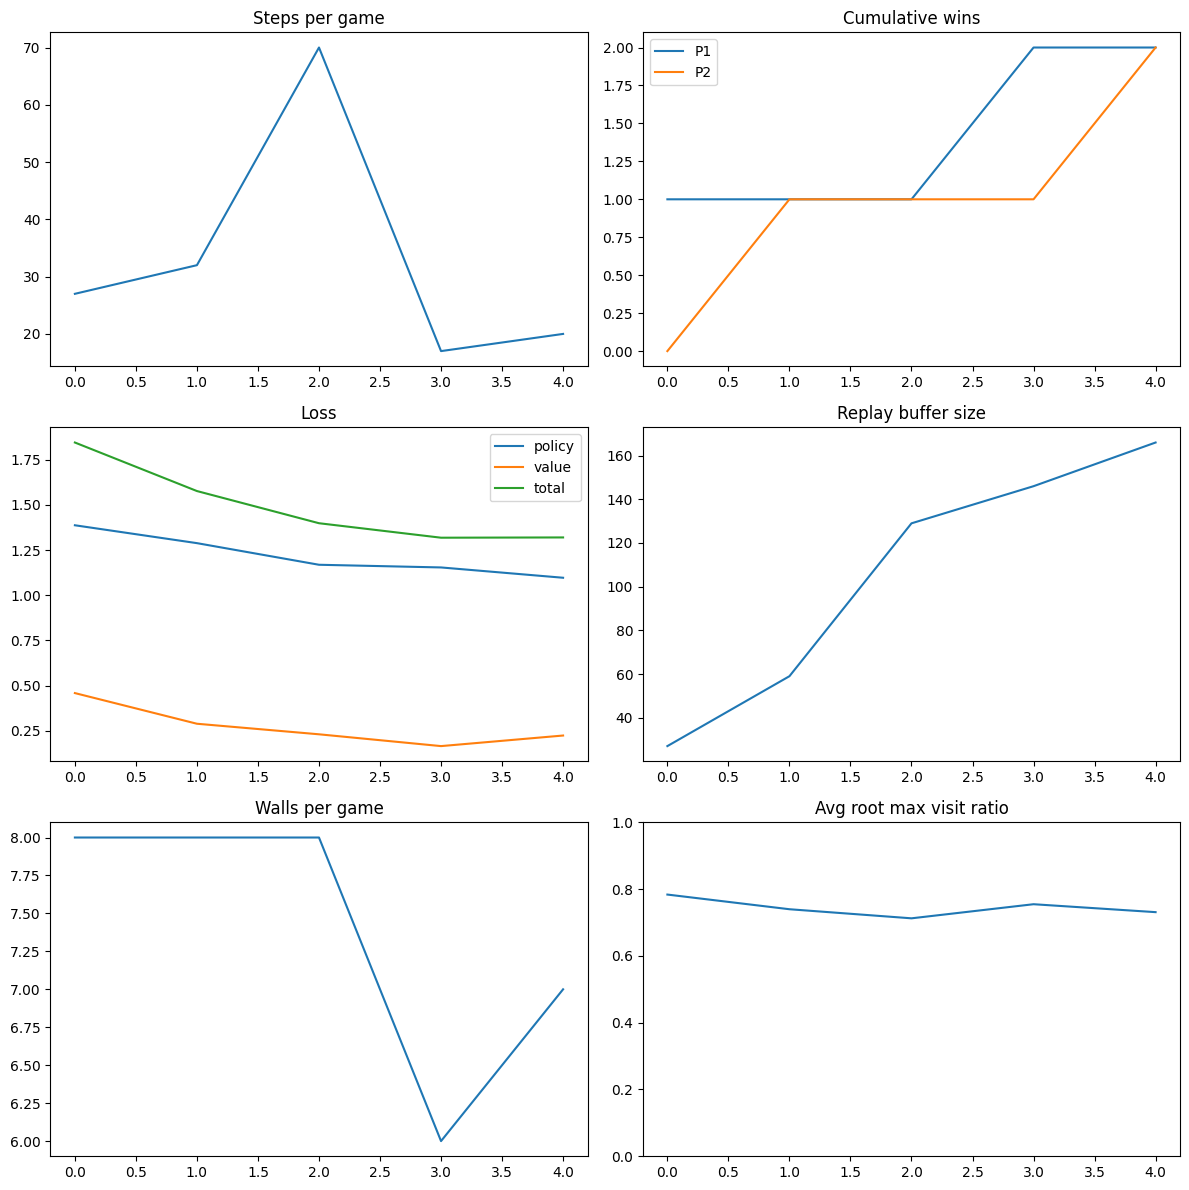

Self-play training: 100%|██████████| 5/5 [02:00<00:00, 24.04s/game, max_visit=0.73, policy_loss=1.097, replay=166, steps=20, value_loss=0.223, winner=2]


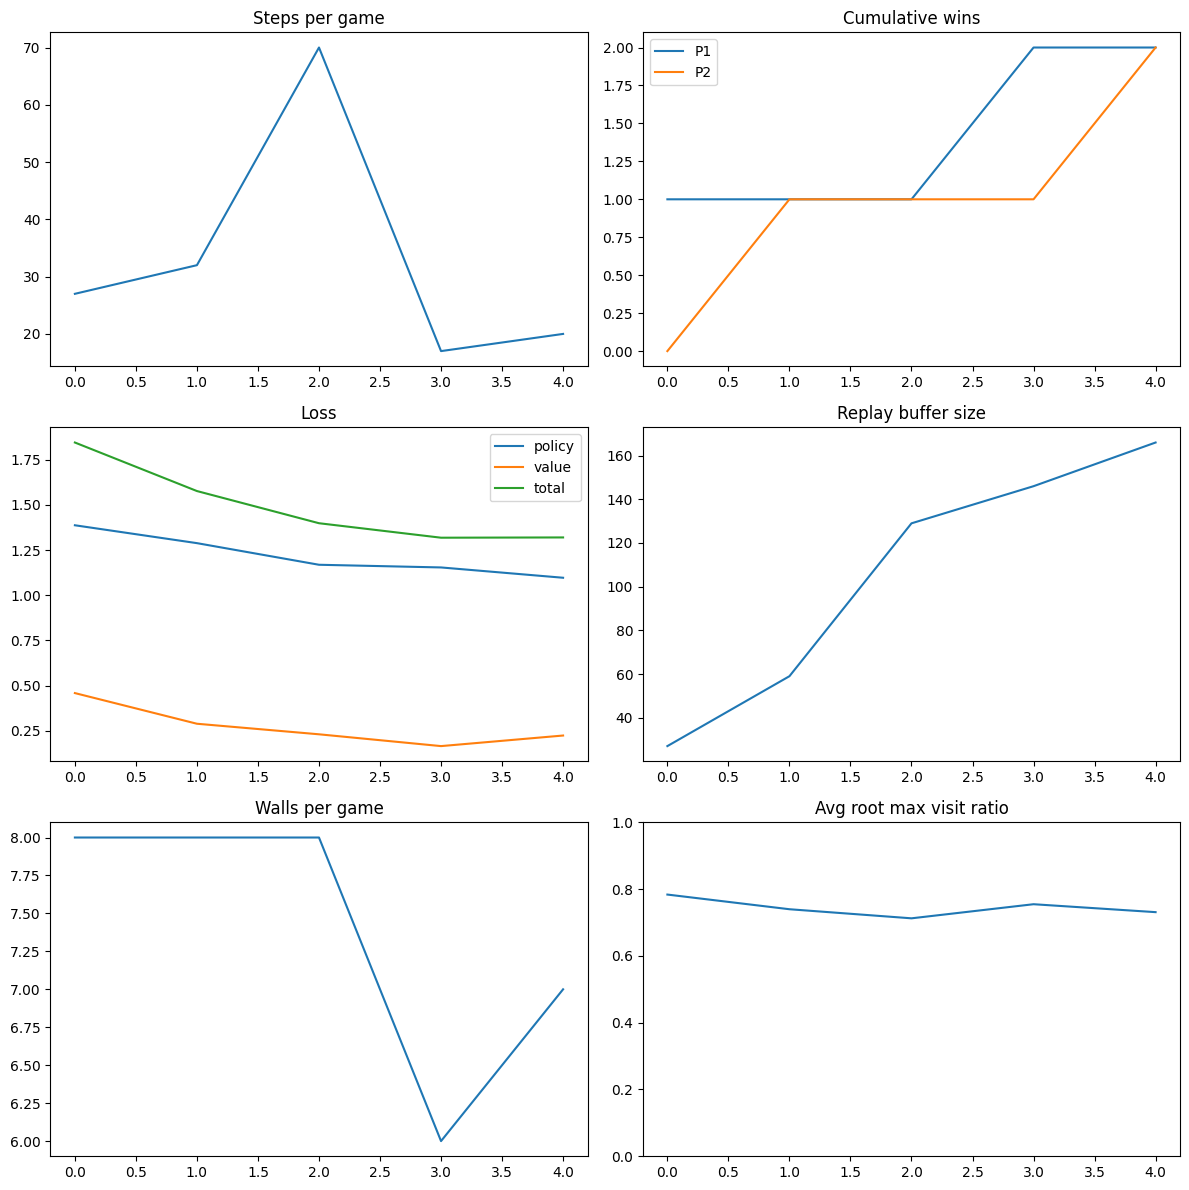

Training finito.
Best model: quoridor_alphazero_runs\run_20260610_224209\models\best_model.pth
Latest model: quoridor_alphazero_runs\run_20260610_224209\models\latest_model.pth
Metrics: quoridor_alphazero_runs\run_20260610_224209\metrics\metrics.csv


In [7]:
# ============================================================
# 7. TRAINING CONFIGURATION AND STARTUP
# ============================================================


CONFIG = {
    'board_size': 5,
    'max_walls': 4,
    'num_games': 5,
    'max_steps_per_game': 70,
    'learning_rate': 2e-4,
    'num_filters': 32,
    'num_simulations': 600,
    'mcts_batch_size': 1,
    'c_puct': 1.5,
    'root_dirichlet_alpha': 0.15,
    'root_dirichlet_epsilon': 0.15,
    # Action temperature controls the move actually played during self-play.
    # e.g. 1.0 samples from MCTS visits; after the drop, 0.0 plays argmax visits.
    'temperature': 1.0,
    'temperature_after_drop': 0.0,
    'temperature_drop_step': 8,
    # Target policy temperature controls the policy label saved for training.
    # e.g. 1.0 keeps soft targets like 70/20/10 instead of one-hot 100/0/0.
    'target_policy_temperature': 1.0,
    # Timeout adjudication controls the weak value target used when a game hits max_steps.
    # 'fixed' uses timeout_adjudication_value; 'proportional' uses shortest-path gap,
    # e.g. abs(p1_dist - p2_dist) / board_size, capped by timeout_adjudication_max_value.
    'timeout_adjudication_mode': 'fixed',
    'timeout_adjudication_value': 0.3,
    'timeout_adjudication_max_value': 0.5,
    'batch_size': 128,
    'train_steps_per_game': 2,
    'plot_every': 5,
    'resume_from_checkpoint': True,
    'checkpoint_path': 'quoridor_alphazero_runs/run_20260602_185704_3500games/models/latest_model.pth',
}

with (RUN_DIR / 'config.json').open('w', encoding='utf-8') as f:
    json.dump(CONFIG, f, indent=2)

env = GridGameAi(grid_size=CONFIG['board_size'], max_walls=CONFIG['max_walls'])
print('Board:', f"{CONFIG['board_size']}x{CONFIG['board_size']}")
print('Max walls per player:', CONFIG['max_walls'])
print('Total action slots:', env.total_actions)
agent = AlphaZeroSelfPlayAgent(
    lr=CONFIG['learning_rate'],
    temperature=CONFIG['temperature'],
    board_size=CONFIG['board_size'],
    max_walls=CONFIG['max_walls'],
    num_actions=env.total_actions,
    num_filters=CONFIG['num_filters'],
)

if CONFIG['resume_from_checkpoint']:
    checkpoint_metadata = agent.load_checkpoint(CONFIG['checkpoint_path'])
    print('Checkpoint loaded from:', CONFIG['checkpoint_path'])
    print('Checkpoint metadata:', checkpoint_metadata)

stats = train_alphazero_self_play(
    env=env,
    agent=agent,
    num_games=CONFIG['num_games'],
    max_steps_per_game=CONFIG['max_steps_per_game'],
    num_simulations=CONFIG['num_simulations'],
    mcts_batch_size=CONFIG['mcts_batch_size'],
    c_puct=CONFIG['c_puct'],
    root_dirichlet_alpha=CONFIG['root_dirichlet_alpha'],
    root_dirichlet_epsilon=CONFIG['root_dirichlet_epsilon'],
    temperature=CONFIG['temperature'],
    temperature_after_drop=CONFIG['temperature_after_drop'],
    temperature_drop_step=CONFIG['temperature_drop_step'],
    target_policy_temperature=CONFIG['target_policy_temperature'],
    timeout_adjudication_value=CONFIG['timeout_adjudication_value'],
    timeout_adjudication_mode=CONFIG['timeout_adjudication_mode'],
    timeout_adjudication_max_value=CONFIG['timeout_adjudication_max_value'],
    batch_size=CONFIG['batch_size'],
    train_steps_per_game=CONFIG['train_steps_per_game'],
    plot_every=CONFIG['plot_every'],
)

print('Training finito.')
print('Best model:', MODEL_DIR / 'best_model.pth')
print('Latest model:', MODEL_DIR / 'latest_model.pth')
print('Metrics:', METRICS_DIR / 'metrics.csv')
